# 🎵 Projeto Final — Inteligência Artificial
## Classificação de Gêneros Musicais via Aprendizado de Máquina


**Aluno:** Igor Ryan de Campos Ianes  
**RA:** 795593 

---

## 1. Introdução

### 1.1 Descrição do problema
O problema abordado consiste em uma tarefa de classificação supervisionada multiclasse, na qual cada música pertence exclusivamente a um dos dez gêneros musicais considerados pelo conjunto de dados

### 1.2 Objetivo
O objetivo deste projeto é desenvolver modelos de aprendizado de máquina capazes de classificar automaticamente o gênero de uma música utilizando características extraídas das suas faixas áudio.

Ao final do projeto, espera-se obter um modelo que apresente boa capacidade de generalização e que possa ser utilizado para classificar automaticamente novas músicas a partir de seus atributos de áudio.

---

## 2. Configurações Iniciais e Importações

Nesta seção, realizamos a importação das bibliotecas necessárias para o desenvolvimento do projeto. Elas estão divididas entre manipulação de dados, visualização gráfica, processamento de áudio e utilitários de aprendizado de máquina.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Configuração dos gráficos
plt.rcParams["figure.figsize"] = (10,5)

---

# 3. Carregamento do Dataset

Nesta etapa realizamos a leitura do conjunto de dados e verificamos sua estrutura inicial.

In [2]:
df = pd.read_csv("dados/features_30_sec.csv")

df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.0645,2002.449060,85882.76132,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.0736,2039.036516,213843.75550,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.6434,1747.702312,76254.19226,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.9424,1596.412872,166441.49480,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.9393,1748.172116,88445.20904,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


---

# 4. Análise Exploratória dos Dados

Nesta etapa verificamos o tamanho do conjunto de dados, os tipos das variáveis e possíveis inconsistências.

### 4.1 Estrutura do dataset

Nesta etapa são apresentadas as principais informações sobre o conjunto de dados, como o número de amostras, a quantidade de atributos e os tipos de dados de cada variável. Essa análise inicial permite compreender a estrutura do dataset e verificar se os dados estão adequados para as etapas seguintes do processo de aprendizagem de máquina.

In [3]:
df.shape

(1000, 60)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

### 4.2 Verificação de valores ausentes

Antes do treinamento dos modelos, é importante verificar a existência de valores ausentes (missing values). A presença desses valores pode comprometer o desempenho dos algoritmos e exigir técnicas de tratamento, como remoção ou imputação. Nesta análise é verificado se o conjunto de dados apresenta atributos incompletos.

In [5]:
df.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

### 4.3 Verificação de duplicatas

Também é realizada a identificação de registros duplicados no conjunto de dados. A existência de amostras repetidas pode introduzir viés no treinamento dos modelos, afetando a capacidade de generalização. Caso sejam encontradas duplicatas, elas devem ser removidas antes da etapa de treinamento.

In [6]:
df.duplicated().sum()

np.int64(0)

### 4.4 Estatisticas

São apresentadas estatísticas descritivas das variáveis numéricas, como média, desvio padrão, valores mínimos, máximos e quartis. Essas informações permitem compreender a distribuição dos atributos extraídos das faixas de áudio e identificar possíveis valores discrepantes.

In [7]:
df.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155166,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666325,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185060,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697312,1.843505e+05,1907.240605,67376.554430,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548050,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576800,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811500,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


### 4.5 Distribuição das classes

A distribuição das classes permite verificar a quantidade de amostras pertencentes a cada gênero musical presente no dataset. Essa análise é importante para identificar possíveis desbalanceamentos entre as classes, situação que pode influenciar diretamente o desempenho dos modelos de classificação.

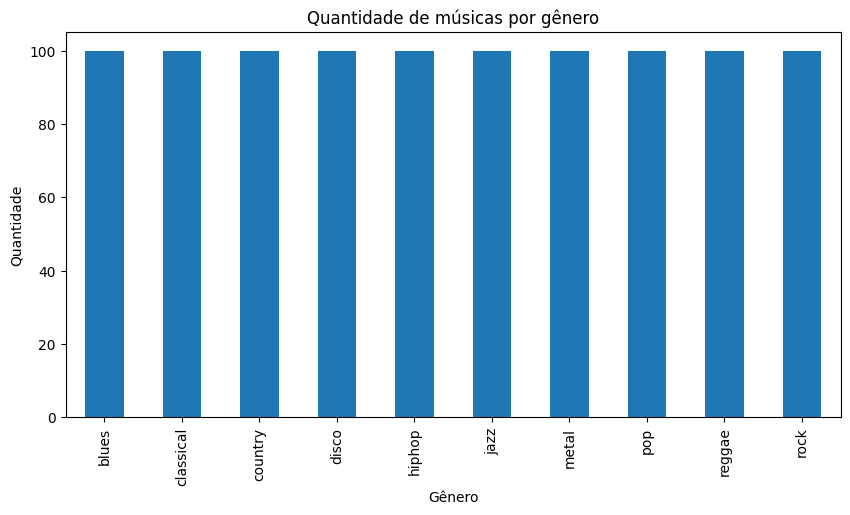

In [8]:
df["label"].value_counts().plot(kind="bar")

plt.title("Quantidade de músicas por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.show()

### 4.6 Distribuição das caracteristicas

Nesta etapa são visualizadas as distribuições dos principais atributos extraídos das músicas. A análise gráfica auxilia na compreensão da variabilidade dos dados, na identificação de possíveis outliers e na observação de padrões que podem contribuir para a distinção entre os diferentes gêneros musicais.
Como o conjunto de dados possui dezenas de características acústicas, foram selecionados alguns atributos representativos para ilustrar a distribuição das principais informações utilizadas pelos modelos de classificação."

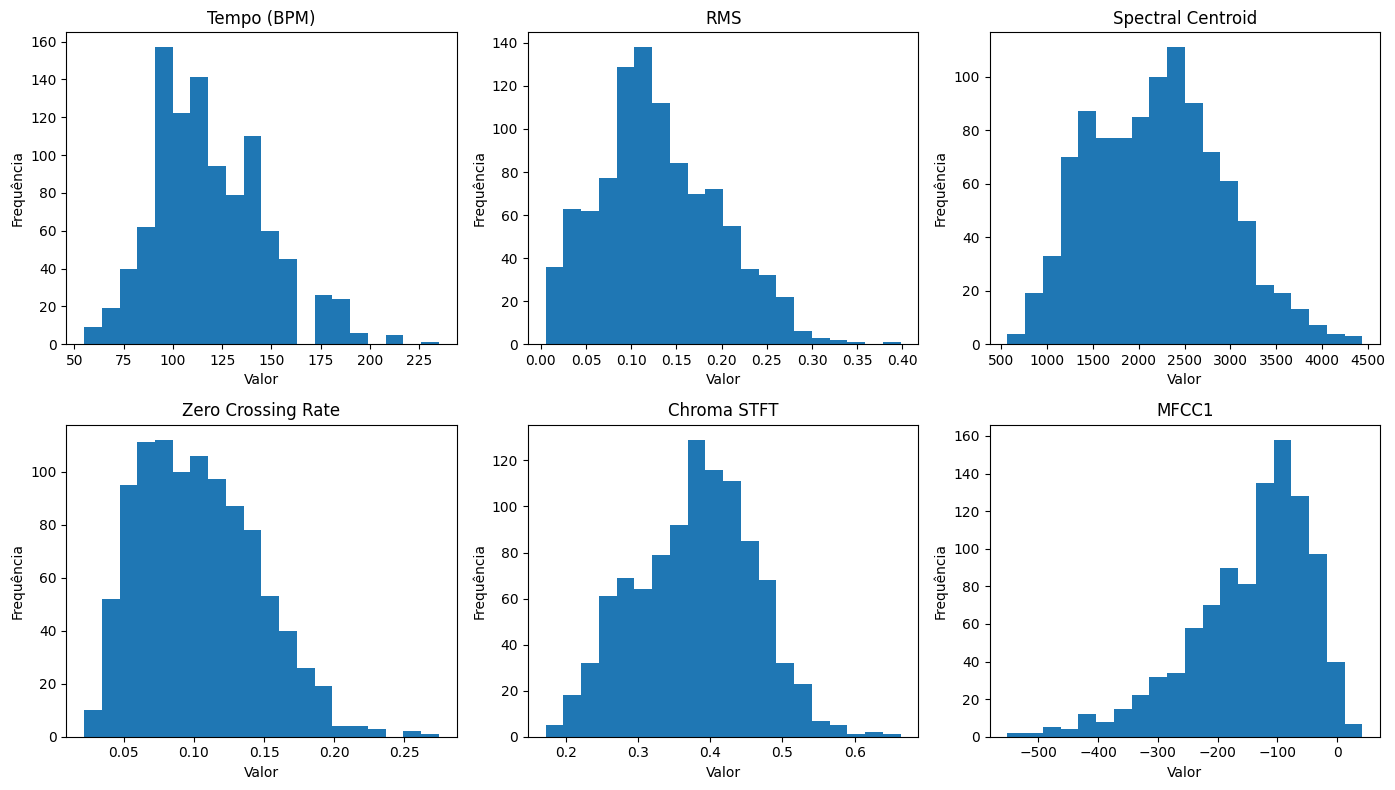

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

atributos = [
    "tempo",
    "rms_mean",
    "spectral_centroid_mean",
    "zero_crossing_rate_mean",
    "chroma_stft_mean",
    "mfcc1_mean"
]

titulos = [
    "Tempo (BPM)",
    "RMS",
    "Spectral Centroid",
    "Zero Crossing Rate",
    "Chroma STFT",
    "MFCC1"
]

for ax, atributo, titulo in zip(axs.ravel(), atributos, titulos):
    ax.hist(df[atributo], bins=20)
    ax.set_title(titulo)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Os graficos apresentam a distribuição de algumas das principais características acústicas presentes no conjunto de dados. Observa-se que os atributos apresentam distribuições distintas, refletindo diferentes propriedades dos sinais de áudio. Essa variabilidade é importante para os algoritmos de aprendizado de máquina, pois fornece informações complementares que auxiliam na distinção entre os diferentes gêneros musicais.

---

# 5. Pré-processamento dos Dados

Nesta etapa, preparamos os dados obtidos para que possam ser consumidos eficientemente pelos algoritmos de aprendizado de máquina. Isto inclui:
1. **Isolamento dos Atributos (X) e do Alvo (y):** Remoção de colunas identificadoras não preditivas (como `filename` e `length`).
2. **Codificação de Variáveis Categóricas:** Conversão dos rótulos de texto (*labels*) em valores numéricos utilizando o `LabelEncoder`.
3. **Divisão do Dataset:** Separação em conjuntos disjuntos de Treino e Teste.
4. **Normalização (Feature Scaling):** Aplicação do `StandardScaler` para colocar todas as características na mesma escala, evitando que atributos com ordens de grandeza maiores distorçam o aprendizado.

### 5.1 Separação entre atributos e classes

Nesta etapa o conjunto de dados é dividido entre as variáveis independentes (atributos) e a variável dependente (classe). Os atributos correspondem às características acústicas extraídas das músicas, enquanto a variável alvo representa o gênero musical associado a cada amostra.

In [10]:
# Removendo colunas que não serão utilizadas

X = df.drop(columns=["filename", "label"])

# Variável alvo

y = df["label"]

print(X.shape)

print(y.shape)

(1000, 58)
(1000,)


### 5.2 Codificação dos rotulos

Como os algoritmos de aprendizado de máquina trabalham com valores numéricos, foi necessária a transformação dos rótulos dos gêneros musicais em valores inteiros. Para isso foi utilizado o LabelEncoder, que associa automaticamente um número para cada classe presente no conjunto de dados.

In [11]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


In [12]:
for i, classe in enumerate(encoder.classes_):
    print(i, "-", classe)

0 - blues
1 - classical
2 - country
3 - disco
4 - hiphop
5 - jazz
6 - metal
7 - pop
8 - reggae
9 - rock


### 5.3 Divisão dos Dados treino/teste

Nesta etapa dividimos o conjunto de dados em treinamento e teste.

- Treinamento: utilizado para ensinar o modelo.
- Teste: utilizado para avaliar o desempenho em dados nunca vistos.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (800, 58)
Teste : (200, 58)


### 5.4 Normalização dos Dados

Foi utilizada a padronização (StandardScaler) para que todas as variáveis possuam média próxima de zero e desvio padrão próximo de um.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

---

# 6. Treinamento dos Modelos

Nesta seção são treinados diferentes algoritmos de classificação supervisionada utilizando o mesmo conjunto de treinamento. O objetivo é comparar o desempenho de cada modelo e identificar aquele que apresenta maior capacidade de generalização para a tarefa de classificação de gêneros musicais.

### 6.1 Modelo 1 - K-Nearest Neighbors (KNN)

O algoritmo K-Nearest Neighbors (KNN) realiza a classificação de uma nova música considerando as amostras mais próximas presentes no conjunto de treinamento. A classe atribuída corresponde ao gênero predominante entre os vizinhos mais próximos, sendo um método simples e amplamente utilizado como referência em problemas de classificação.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

#### Predição no conjunto de teste

Após o treinamento do modelo, são realizadas predições utilizando o conjunto de teste, composto por dados não apresentados durante o aprendizado. Essa etapa permite avaliar a capacidade de generalização do algoritmo.

In [16]:
y_pred = knn.predict(X_test)

#### Avaliação do modelo

O desempenho do modelo é avaliado por meio da acurácia e do relatório de classificação. Essas métricas permitem analisar a qualidade das predições realizadas para cada gênero musical.

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.6750


#### Relatório de classificação

O relatório de classificação apresenta métricas como precisão (Precision), revocação (Recall), F1-Score e suporte para cada classe. Essas medidas oferecem uma avaliação mais detalhada do desempenho do modelo do que apenas a acurácia.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        20
   classical       0.82      0.90      0.86        20
     country       0.55      0.90      0.68        20
       disco       0.43      0.45      0.44        20
      hiphop       0.62      0.65      0.63        20
        jazz       0.80      0.60      0.69        20
       metal       0.94      0.75      0.83        20
         pop       0.85      0.85      0.85        20
      reggae       0.60      0.45      0.51        20
        rock       0.57      0.60      0.59        20

    accuracy                           0.68       200
   macro avg       0.69      0.68      0.67       200
weighted avg       0.69      0.68      0.67       200



#### Matriz de confusão

A matriz de confusão apresenta a comparação entre os valores reais e os valores preditos pelo modelo. Sua análise permite identificar quais gêneros musicais são classificados corretamente e quais apresentam maior índice de confusão.

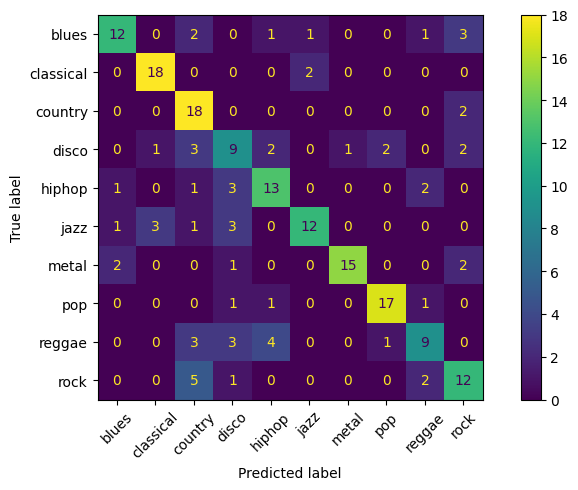

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test,
    y_test,
    display_labels=encoder.classes_,
    xticks_rotation=45
)

plt.show()

A matriz de confusão indica que o KNN foi capaz de classificar corretamente uma parcela significativa das músicas, porém apresentou confusão entre alguns gêneros com características acústicas semelhantes. Esse comportamento é esperado, uma vez que o algoritmo baseia suas decisões na proximidade entre as amostras no espaço de atributos.

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultado_knn = {
    "Acurácia": accuracy,
    "Precisão": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted")
}

#### Função de treinamento e avaliação

Para evitar duplicação de código, foi implementada uma função responsável por realizar o treinamento, gerar as predições e calcular as métricas de desempenho de qualquer algoritmo de classificação. Essa abordagem torna o código mais organizado, reutilizável e de fácil manutenção.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

def avaliar_modelo(nome, modelo):

    # Treinamento
    modelo.fit(X_train, y_train)

    # Predições
    y_pred = modelo.predict(X_test)

    # Acurácia
    acuracia = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(f"Modelo: {nome}")
    print(f"Acurácia: {acuracia:.4f}")
    print("=" * 60)

    # Relatório
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_test, y_pred))

    # Matriz de confusão
    print("\nMatriz de Confusão:\n")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

    return acuracia

### 6.2 Modelo 2 - Arvore de decisão

O algoritmo de Árvore de Decisão realiza a classificação por meio de sucessivas divisões do conjunto de dados, formando uma estrutura hierárquica semelhante a uma árvore. Em cada nó é escolhido o atributo que melhor separa as classes de acordo com critérios como ganho de informação ou índice de Gini. O processo continua até que sejam atingidas folhas representando as classes finais. Esse modelo possui fácil interpretação e permite compreender quais características dos dados foram mais relevantes para a tomada de decisão.

Modelo: Árvore de Decisão
Acurácia: 0.6000

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.63      0.60      0.62        20
           1       0.73      0.80      0.76        20
           2       0.42      0.50      0.45        20
           3       0.48      0.50      0.49        20
           4       0.68      0.65      0.67        20
           5       0.69      0.55      0.61        20
           6       0.65      0.65      0.65        20
           7       0.81      0.85      0.83        20
           8       0.58      0.55      0.56        20
           9       0.37      0.35      0.36        20

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.60      0.60      0.60       200


Matriz de Confusão:



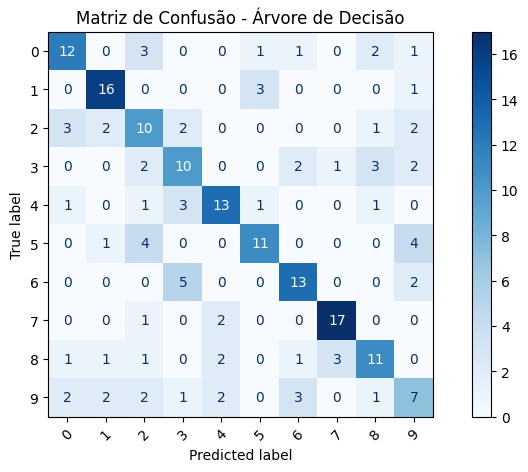

In [22]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(random_state=42)

resultado_arvore = avaliar_modelo(
    "Árvore de Decisão",
    arvore
)

Observa-se que a Árvore de Decisão apresentou maior dispersão dos erros entre as classes, indicando menor capacidade de generalização quando comparada aos demais algoritmos avaliados.

### 6.3 Modelo 3 - Random forrest

O Random Forest é um método de aprendizado baseado em conjuntos (ensemble learning) que combina diversas árvores de decisão para produzir uma classificação mais robusta. Cada árvore é treinada utilizando subconjuntos aleatórios dos dados e dos atributos disponíveis, reduzindo o risco de sobreajuste (overfitting) observado em uma única árvore de decisão. A predição final é obtida por votação entre todas as árvores da floresta, proporcionando maior estabilidade e, geralmente, melhor desempenho em tarefas de classificação.

Modelo: Random Forest
Acurácia: 0.7750

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.86      0.95      0.90        20
           2       0.68      0.75      0.71        20
           3       0.71      0.60      0.65        20
           4       0.65      0.75      0.70        20
           5       0.77      0.85      0.81        20
           6       0.89      0.85      0.87        20
           7       0.86      0.90      0.88        20
           8       0.76      0.80      0.78        20
           9       0.73      0.55      0.63        20

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200


Matriz de Confusão:



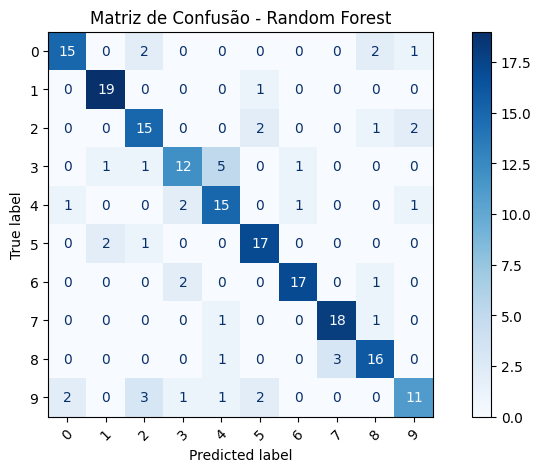

In [23]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42
)

resultado_rf = avaliar_modelo(
    "Random Forest",
    random_forest
)

A matriz de confusão do Random Forest apresenta maior concentração de valores na diagonal principal, indicando maior número de classificações corretas. Esse comportamento confirma o melhor desempenho obtido pelo algoritmo em termos de acurácia.

### 6.4 Modelo 4 - Support Vector Machine (SMV)

O Support Vector Machine (SVM) é um algoritmo de classificação supervisionada que busca encontrar um hiperplano capaz de separar as diferentes classes com a maior margem possível. Quando os dados não são linearmente separáveis, o algoritmo pode utilizar funções de kernel para projetá-los em espaços de maior dimensão, permitindo a construção de fronteiras de decisão mais complexas. O SVM é amplamente utilizado em problemas de classificação devido à sua elevada capacidade de generalização.

Modelo: Support Vector Machine
Acurácia: 0.7350

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.95      1.00      0.98        20
           2       0.83      0.75      0.79        20
           3       0.56      0.45      0.50        20
           4       0.80      0.80      0.80        20
           5       0.71      0.85      0.77        20
           6       0.80      0.80      0.80        20
           7       0.82      0.70      0.76        20
           8       0.56      0.75      0.64        20
           9       0.55      0.55      0.55        20

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200


Matriz de Confusão:



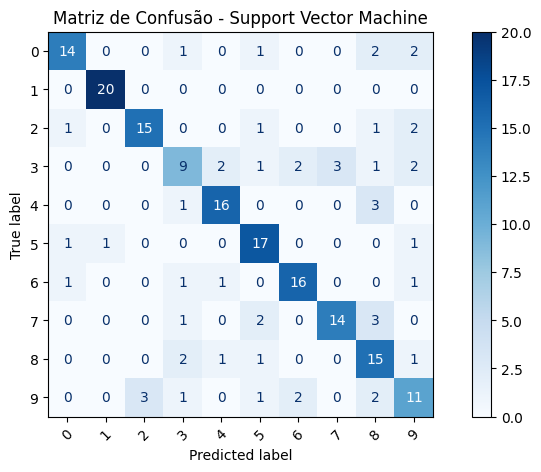

In [24]:
from sklearn.svm import SVC

svm = SVC()

resultado_svm = avaliar_modelo(
    "Support Vector Machine",
    svm
)

O SVM apresentou uma matriz de confusão com boa concentração de acertos na diagonal principal, demonstrando elevada capacidade de separação entre os gêneros musicais, embora ainda existam confusões entre algumas classes.

### 6.5 Modelo 5 - Multilayer Perceptron (MLP)

A Rede Neural Multicamadas (Multilayer Perceptron - MLP) é composta por neurônios artificiais organizados em camadas de entrada, ocultas e saída. Durante o treinamento, os pesos das conexões são ajustados por meio do algoritmo de retropropagação do erro (Backpropagation), permitindo que a rede aprenda relações complexas entre os atributos de entrada e as classes de saída. Redes neurais são especialmente eficientes na identificação de padrões não lineares presentes em grandes conjuntos de dados.

Modelo: MLP
Acurácia: 0.7600

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.95      0.90      0.92        20
           2       0.79      0.75      0.77        20
           3       0.65      0.55      0.59        20
           4       0.81      0.85      0.83        20
           5       0.81      0.85      0.83        20
           6       0.88      0.70      0.78        20
           7       0.80      0.80      0.80        20
           8       0.65      0.75      0.70        20
           9       0.59      0.65      0.62        20

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200


Matriz de Confusão:



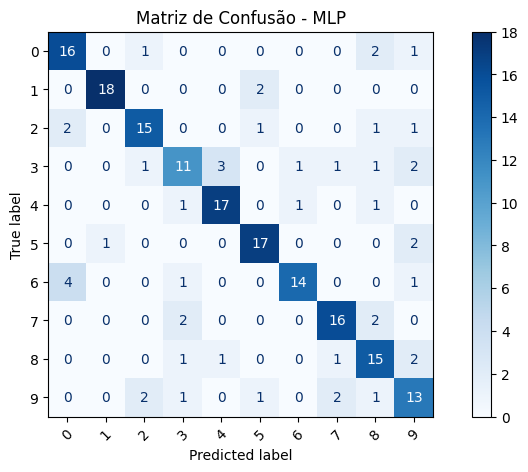

In [25]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42
)

resultado_mlp = avaliar_modelo(
    "MLP",
    mlp
)

A Rede Neural MLP apresentou desempenho competitivo, classificando corretamente a maioria das amostras. Entretanto, ainda foram observados erros de classificação entre gêneros com características acústicas semelhantes.

---

# 7. Comparação entre modelos

Após a avaliação individual de cada algoritmo, foi realizada uma comparação conjunta dos modelos utilizando as métricas de acurácia, precisão, recall e F1-Score obtidas no conjunto de teste. Essa análise permite identificar qual algoritmo apresentou melhor capacidade de generalização e desempenho global na tarefa de classificação de gêneros musicais.

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def obter_metricas(modelo):

    y_pred = modelo.predict(X_test)

    return {
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    }

As métricas dos modelos foram reunidas em uma única estrutura de dados, permitindo a comparação direta entre os algoritmos avaliados.


In [27]:
resultado_knn = {
    "Acurácia": accuracy,
    "Precisão": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted")
}

resultado_arvore = obter_metricas(arvore)
resultado_rf = obter_metricas(random_forest)
resultado_svm = obter_metricas(svm)
resultado_mlp = obter_metricas(mlp)

Para facilitar a análise comparativa, as métricas obtidas por cada modelo foram organizadas em uma tabela.

In [28]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": [
        "KNN",
        "Árvore de Decisão",
        "Random Forest",
        "SVM",
        "MLP"
    ],
    "Acurácia": [
        resultado_knn["Acurácia"],
        resultado_arvore["Acurácia"],
        resultado_rf["Acurácia"],
        resultado_svm["Acurácia"],
        resultado_mlp["Acurácia"]
    ],
    "Precisão": [
        resultado_knn["Precisão"],
        resultado_arvore["Precisão"],
        resultado_rf["Precisão"],
        resultado_svm["Precisão"],
        resultado_mlp["Precisão"]
    ],
    "Recall": [
        resultado_knn["Recall"],
        resultado_arvore["Recall"],
        resultado_rf["Recall"],
        resultado_svm["Recall"],
        resultado_mlp["Recall"]
    ],
    "F1-Score": [
        resultado_knn["F1-Score"],
        resultado_arvore["F1-Score"],
        resultado_rf["F1-Score"],
        resultado_svm["F1-Score"],
        resultado_mlp["F1-Score"]
    ]
})

As tabelas a seguir apresentam o desempenho dos algoritmos considerando cada uma das métricas de avaliação utilizadas neste trabalho.

In [29]:
resultados[["Modelo","Acurácia"]].sort_values(
    "Acurácia",
    ascending=False
)

,Modelo,Acurácia
2,Random Forest,0.775
4,MLP,0.760
3,SVM,0.735
0,KNN,0.675
1,Árvore de Decisão,0.600


Observa-se que o Random Forest apresentou a maior acurácia (77,5%), seguido pelo MLP (76,0%) e pelo SVM (73,5%). O KNN obteve desempenho intermediário, enquanto a Árvore de Decisão apresentou o menor desempenho entre os modelos avaliados.

In [30]:
resultados[["Modelo","Precisão"]].sort_values(
    "Precisão",
    ascending=False
)

,Modelo,Precisão
2,Random Forest,0.775669
4,MLP,0.764830
3,SVM,0.740916
0,KNN,0.692018
1,Árvore de Decisão,0.603031


Os resultados de precisão confirmam a superioridade do Random Forest, indicando que esse modelo apresentou maior proporção de classificações corretas entre as previsões realizadas. O MLP e o SVM também apresentaram desempenho consistente, enquanto a Árvore de Decisão obteve os menores valores.

In [31]:
resultados[["Modelo","Recall"]].sort_values(
    "Recall",
    ascending=False
)

,Modelo,Recall
2,Random Forest,0.775
4,MLP,0.760
3,SVM,0.735
0,KNN,0.675
1,Árvore de Decisão,0.600


Os valores de recall seguiram tendência semelhante à observada na acurácia, demonstrando que o Random Forest recuperou corretamente a maior quantidade de amostras pertencentes a cada classe. Os demais algoritmos mantiveram a mesma ordem de desempenho observada anteriormente.

In [32]:
resultados[["Modelo","F1-Score"]].sort_values(
    "F1-Score",
    ascending=False
)

,Modelo,F1-Score
2,Random Forest,0.772327
4,MLP,0.760184
3,SVM,0.733962
0,KNN,0.674492
1,Árvore de Decisão,0.599976


O F1-Score apresentou comportamento semelhante ao observado nas demais métricas, com destaque para o Random Forest, que alcançou o maior valor entre os algoritmos avaliados. Como essa métrica representa a média harmônica entre precisão e recall, seu resultado indica que o modelo manteve um bom equilíbrio entre a capacidade de realizar previsões corretas e de identificar corretamente as classes. O MLP apresentou desempenho próximo ao Random Forest, seguido pelo SVM e pelo KNN, enquanto a Árvore de Decisão obteve o menor F1-Score.

#### Conclusão

A comparação das quatro métricas demonstra que o Random Forest apresentou o melhor desempenho geral, obtendo os maiores valores de acurácia, precisão, recall e F1-Score. O MLP apresentou resultados bastante próximos, configurando-se como uma alternativa competitiva. O SVM também apresentou desempenho satisfatório, enquanto o KNN obteve resultados intermediários. A Árvore de Decisão foi o modelo com menor capacidade de generalização para o conjunto de dados utilizado.

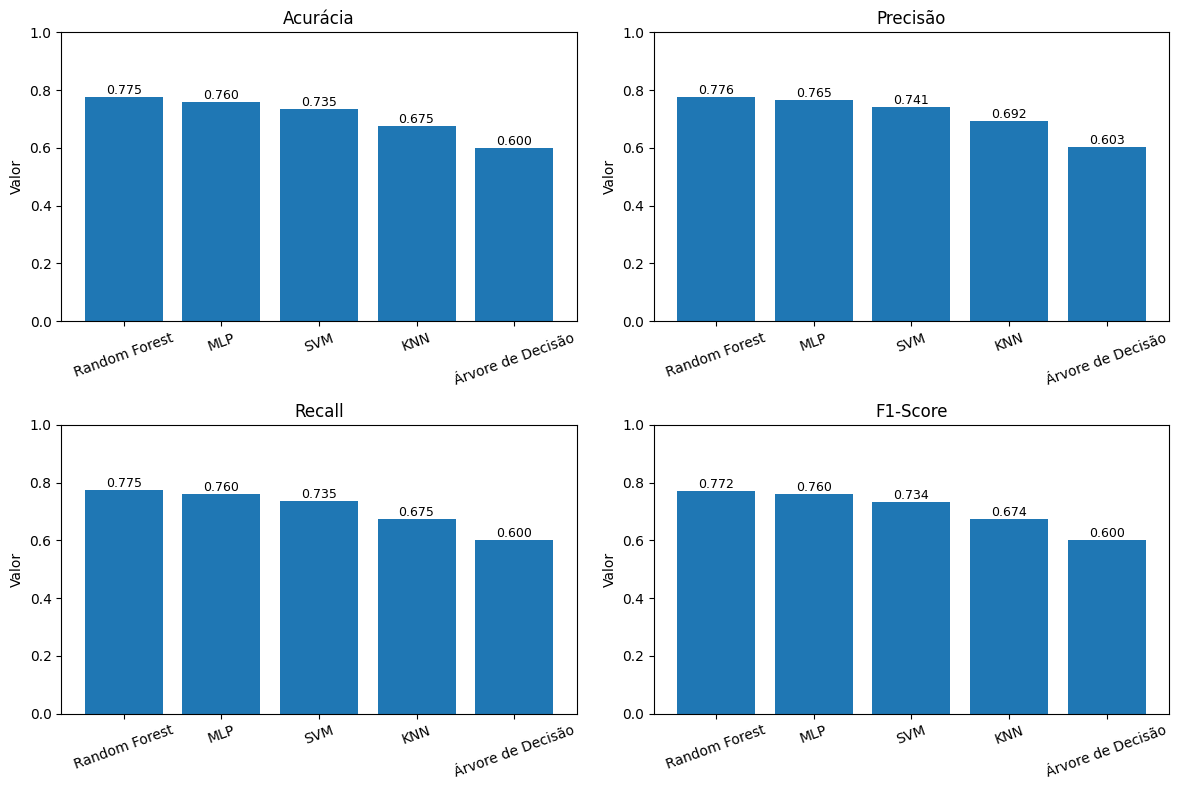

In [33]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

metricas = [
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-Score"
]

for ax, metrica in zip(axs.ravel(), metricas):

    ranking = resultados.sort_values(
        by=metrica,
        ascending=False
    )

    barras = ax.bar(
        ranking["Modelo"],
        ranking[metrica]
    )

    ax.set_title(metrica)
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.01,
            f"{altura:.3f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

Com base nesses resultados, o Random Forest foi selecionado como modelo final do sistema, sendo utilizado na etapa de classificação de novas faixas de áudio devido ao seu melhor desempenho e maior equilíbrio entre todas as métricas avaliadas.

---

# 8. Seleção do melhor modelo

Com base nos resultados obtidos, o modelo Random Forest apresentou o melhor desempenho entre os algoritmos avaliados, alcançando aproximadamente 77,5% de acurácia. Dessa forma, esse modelo foi escolhido para ser persistido em disco e utilizado na etapa de inferência sobre novas músicas.

In [34]:
import joblib

joblib.dump(random_forest, "modelo_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


### 8.1 Carregando o modelo

Após a seleção do modelo com melhor desempenho, ele é carregado para ser utilizado na etapa de inferência. Esse procedimento demonstra como um modelo previamente treinado pode ser reutilizado sem a necessidade de repetir todo o processo de treinamento.

In [35]:
modelo = joblib.load("modelo_random_forest.pkl")

---

# 9. Classificação de novos audios

Uma vez salvo o modelo escolhido, neste caso, o Random Forest, é possivel carregar o arquivo 'modelo_random_forest.pkl' em um script python e efetuar a classificação de novas faixas de audio.

---

# 10. Conclusão

Neste projeto foram avaliados diferentes algoritmos de aprendizado supervisionado para a classificação automática de gêneros musicais utilizando atributos extraídos de sinais de áudio. Entre os modelos analisados, o Random Forest apresentou o melhor desempenho, alcançando aproximadamente 77,5% de acurácia, sendo selecionado para utilização na etapa de inferência sobre novas músicas. Os resultados demonstram que técnicas de aprendizado de máquina são capazes de identificar padrões relevantes em características espectrais e temporais do áudio, permitindo a classificação automática de gêneros musicais com desempenho satisfatório.

---